In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# models generation directory: LLM4DC/CoT.response
# predicted dataset by model:  LLM4DC/CoT.response/{model}/datasets_llm
# predicted workflow by model:  LLM4DC/CoT.response/{model}/recipes_llm
# predicted operations by model:  LLM4DC/CoT.response/{model}/operation
# logging:  LLM4DC/CoT.response/logging

# all the sample tables are under: LLM4DC/datasets
# query: 1-30 [menu]: LLM4DC/datasets/menu_datasets
# clean table (ground truth) LLM4DC/datasets/menu_datasets/clean_tables/
# clean workflow (silver ground truth):  LLM4DC/datasets/menu_datasets/workflows

# query: 31-61 [chicago]: LLM4DC/datasets/CFI_datasets
# clean table (ground truth): LLM4DC/datasets/CFI_datasets/cleaned_tables/
# clean workflow (silver ground truth):  LLM4DC/datasets/CFI_datasets/workflows

# query: 62-91 [ppp]:LLM4DC/datasets/ppp_datasets
# clean table (ground truth): LLM4DC/datasets/ppp_datasets/cleaned_tables/
# clean workflow (silver ground truth):  LLM4DC/datasets/ppp_datasets/workflows

# query: 92-110 [dish]: LLM4DC/datasets/dish_datasets
# clean table (ground truth): LLM4DC/datasets/dish_datasets/cleaned_tables/
# clean workflow (silver ground truth):  LLM4DC/datasets/dish_datasets/workflows

# query: 111-126 [flights]: LLM4DC/datasets/flights
# clean table (ground truth): LLM4DC/datasets/flights/cleaned_tables/flights_data_p{query_id}.csv
# clean workflow (silver ground truth):  LLM4DC/datasets/flights/workflows/flights_p{query_id}.json

# query: 127- 154 [hospital]: LLM4DC/datasets/hospital
# clean table (ground truth): LLM4DC/datasets/hospital/clean_tables/
# clean workflow (silver ground truth):  LLM4DC/datasets/hospital/workflows

In [2]:
import re

In [2]:
import json

In [3]:
import ast
# LLM-based history update solution
import importlib.util
import inspect
from typing import List
import requests
import json
import re
import difflib
from collections import Counter
# from spellchecker import SpellChecker
from datetime import datetime
import pandas as pd
import ast
import random
import logging 
# from history_update_problem.call_or import export_rows
from call_or import *
from evaluation import *

In [6]:
models = ['llama3.1',  'mistral', 'gemma2','gemma2base']
base_models = ['llama3.1',  'mistral', 'gemma2','gemma2base'] # locate in ablation folder

# Worflow eval

In [45]:
def eval_workflows(pp_id, gt_wf_fp, pred_wf_fp):
    # print(gt_wf_fp)
    if not os.path.exists(pred_wf_fp):
        pred_ops_list = {
                pp_id: []
            }
    else:
        pred_ops_list = parse_recipe(pp_id, recipe=pred_wf_fp)
        print(pred_ops_list)
    gt_ops_list = parse_recipe(pp_id, recipe=gt_wf_fp)
    return {'pp_id': pp_id, 'gt_ops': gt_ops_list[pp_id], 'pred_ops': pred_ops_list[pp_id]}
    # print(gt_ops_list)
    # print(pred_ops_list)

answer_gt_path = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_gt.json'
answer_preds_llama = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_llama3.1.json'


# eval_table_results = eval_answers(answer_gt_path, answer_preds_llama)
# model = models[0]
wf_gt_folder = '/projects/bces/lanl2/LLM4DC/datasets'

query_contents = pd.read_csv('/projects/bces/lanl2/LLM4DC/purposes/all_purposes.csv')
    
ops_result = {}
for model in models[:]:
    ops_list = []

    wf_pred_folder = f'/projects/bces/lanl2/LLM4DC/ablation/{model}/recipes_llm'
    for query_id in range(155):
        row = query_contents[query_contents['ID'] == query_id]
        if len(row) == 0:
            continue
        # if model == 'llama3.1':
        if query_id >126:
            #TODO: what's the point to have the target_path here? 
            target_path = f'{wf_gt_folder}/hospital/clean_tables/hos_pp{query_id}.csv'
            wf_gt_fp = f"{wf_gt_folder}/hospital/workflows/hos_p{query_id}.json"
            wf_pred_fp = f"{wf_pred_folder}/base_{model}_hos_test_p{query_id}.json"
            
        elif query_id >= 111 and query_id <=126:
            target_path = f'{wf_gt_folder}/flights/cleaned_tables/flights_data_p{query_id}.csv'
            wf_gt_fp = f"{wf_gt_folder}/flights/workflows/flights_p{query_id}.json"
            wf_pred_fp = f"{wf_pred_folder}/base_{model}_flights_test_p{query_id}.json"
            
        elif query_id >= 92 and query_id <=110:
            target_path = f'{wf_gt_folder}/dish_datasets/cleaned_tables/dish_sample_p{query_id}.csv'
            wf_gt_fp = f"{wf_gt_folder}/dish_datasets/workflows/dish_sample_p{query_id}.json"
            wf_pred_fp = f"{wf_pred_folder}/base_{model}_dish_test_p{query_id}.json"
            
        elif query_id >= 62 and query_id <= 91:
            target_path = f'{wf_gt_folder}/ppp_datasets/cleaned_tables/ppp_sample_p{query_id}.csv'
            wf_gt_fp = f"{wf_gt_folder}/ppp_datasets/workflows/ppp_sample_p{query_id}.json"
            wf_pred_fp = f"{wf_pred_folder}/base_{model}_ppp_test_p{query_id}.json"
            
        elif query_id >= 31 and query_id <= 61:
            target_path = f'{wf_gt_folder}/CFI_datasets/cleaned_tables/chi_sample_p{query_id}.csv'
            wf_gt_fp = f"{wf_gt_folder}/CFI_datasets/workflows/chi_sample_p{query_id}.json"
            wf_pred_fp = f"{wf_pred_folder}/base_{model}_chi_test_p{query_id}.json"
            
        elif query_id <31:
            target_path = f'{wf_gt_folder}/menu_datasets/clean_tables/menu_sample_p{query_id}'
            wf_gt_fp = f"{wf_gt_folder}/menu_datasets/workflows/menu_sample_p{query_id}.json"
            wf_pred_fp = f"{wf_pred_folder}/base_{model}_menu_test_p{query_id}.json"
            
        # if wf_gt_fp and wf_pred_fp:
        ops_list.append(eval_workflows(query_id, wf_gt_fp, wf_pred_fp))
    ops_result[model] = pd.DataFrame(ops_list)
# ops_df = pd.DataFrame(ops_list)

{1: []}
{2: ['numeric']}
{3: []}
{4: []}
{5: []}
{6: []}
{7: []}
{8: []}
{9: []}
{10: []}
{11: []}
{12: []}
{14: []}
{15: ['trim']}
{16: []}
{17: []}
{18: []}
{19: []}
{20: []}
{21: []}
{22: ['trim']}
{23: []}
{24: []}
{25: ['trim']}
{26: ['date']}
{27: ['date', 'numeric', 'numeric']}
{29: []}
{30: []}
{32: []}
{33: []}
{34: []}
{35: []}
{36: []}
{37: ['text_transform', 'trim']}
{39: []}
{40: []}
{41: ['text_transform', 'trim']}
{43: ['text_transform']}
{44: []}
{45: []}
{46: []}
{47: []}
{48: []}
{49: ['trim', 'numeric']}
{50: []}
{51: []}
{53: []}
{54: ['date']}
{55: []}
{56: ['text_transform']}
{57: ['text_transform', 'date']}
{58: []}
{59: ['date']}
{60: ['date']}
{62: ['numeric']}
{63: ['numeric']}
{64: ['numeric']}
{65: ['numeric']}
{66: ['numeric', 'numeric']}
{69: ['text_transform', 'numeric']}
{70: ['numeric']}
{73: ['trim', 'numeric']}
{74: ['trim', 'numeric']}
{75: ['numeric', 'numeric']}
{76: ['trim', 'numeric']}
{77: ['numeric']}
{80: ['text_transform', 'numeric']}
{81: ['

In [46]:
def parse_mean(df, col_name):
    total_wf = df.describe().loc['mean']
    # total_wf.columns = [col_name] #rename(columns={"mean": col_name})
    return total_wf

In [47]:
ops_single = list(ops_result.values())[0]
ops_single.columns


Index(['pp_id', 'gt_ops', 'pred_ops'], dtype='object')

In [10]:
ops_single = pd.read_csv('/projects/bces/lanl2/LLM4DC/dataset-all - all_purposes.csv')

In [11]:
for i, x in zip(ops_single['pp_id'], ops_single['gt_ops']):
    if 'column_split' in x:
        print(i, x)

KeyError: 'pp_id'

In [41]:
ops_single

,ID,Purposes,tg_columns,Operations,Category,Unnamed: 5
0,1,Find the longest menu served (by page count).,page_count,numeric,Descriptive Statistics,NaN
1,2,What is the average page numbers for the menus?,page_count,numeric,Descriptive Statistics,NaN
2,3,Determine the number of distinct event types i...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
3,4,List number of rows where the menu event is sp...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
4,5,List number of rows where the menu event is ma...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
...,...,...,...,...,...,...
137,150,How many hospital types offer emergency services.,"HospitalType, EmergencyService","trim, regexr_transform, mass_edit, upper",Filtering and Specific Queries,NaN
138,151,Query hospitals in cities with voluntary non-p...,"City, HospitalOwner, HospitalType","trim, regexr_transform, mass_edit, upper",Filtering and Specific Queries,NaN
139,152,Identify cities where government-owned hospita...,"HospitalOwner, City","trim, mass_edit, upper, regexr_transform",Category or Type Classification,NaN
140,153,Determine the relationship between ZIP code de...,"ZipCode, EmergencyService","trim, mass_edit, upper, numeric",Correlations and Relationships,NaN


In [43]:
from collections import Counter

In [15]:
def parse_ops_list(ops_df, dataset_name):
    flights_ops_list = []
    for op in ops_df:
        flights_ops_list += op
    flights_ops_result = dict(Counter(flights_ops_list))
    for key in ["upper", "trim", "mass_edit", "regexr_transform", "numeric", "date"]:
        if key not in flights_ops_result.keys():
            flights_ops_result[key] = 0
    flights_ops_result['dataset'] = dataset_name
    return flights_ops_result


In [24]:
ops_df

,ID,Purposes,tg_columns,Operations,Category,Unnamed: 5
0,1,Find the longest menu served (by page count).,page_count,numeric,Descriptive Statistics,NaN
1,2,What is the average page numbers for the menus?,page_count,numeric,Descriptive Statistics,NaN
2,3,Determine the number of distinct event types i...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
3,4,List number of rows where the menu event is sp...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
4,5,List number of rows where the menu event is ma...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
...,...,...,...,...,...,...
137,150,How many hospital types offer emergency services.,"HospitalType, EmergencyService","trim, regexr_transform, mass_edit, upper",Filtering and Specific Queries,NaN
138,151,Query hospitals in cities with voluntary non-p...,"City, HospitalOwner, HospitalType","trim, regexr_transform, mass_edit, upper",Filtering and Specific Queries,NaN
139,152,Identify cities where government-owned hospita...,"HospitalOwner, City","trim, mass_edit, upper, regexr_transform",Category or Type Classification,NaN
140,153,Determine the relationship between ZIP code de...,"ZipCode, EmergencyService","trim, mass_edit, upper, numeric",Correlations and Relationships,NaN


In [60]:
ops_single.set_index('ID')

,Purposes,tg_columns,Operations,Category,Unnamed: 5
ID,,,,,
1,Find the longest menu served (by page count).,page_count,numeric,Descriptive Statistics,NaN
2,What is the average page numbers for the menus?,page_count,numeric,Descriptive Statistics,NaN
3,Determine the number of distinct event types i...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
4,List number of rows where the menu event is sp...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
5,List number of rows where the menu event is ma...,event,"trim, mass_edit, upper",Counting and Grouping,NaN
...,...,...,...,...,...
150,How many hospital types offer emergency services.,"HospitalType, EmergencyService","trim, regexr_transform, mass_edit, upper",Filtering and Specific Queries,NaN
151,Query hospitals in cities with voluntary non-p...,"City, HospitalOwner, HospitalType","trim, regexr_transform, mass_edit, upper",Filtering and Specific Queries,NaN
152,Identify cities where government-owned hospita...,"HospitalOwner, City","trim, mass_edit, upper, regexr_transform",Category or Type Classification,NaN


In [53]:
def parse_ops(ops):
    if type(ops) == str:
        ops = ops.split(',')
        ops = [op.strip() for op in ops]
    else:
        ops = [op.strip() for op in ops]
    return ops

In [64]:
ops_df.loc[111:127]['Operations']

111                [regexr_transform, trim, date, upper]
112     [regexr_transform, trim, upper, mass_edit, date]
113                [regexr_transform, trim, date, upper]
114                             [trim, upper, mass_edit]
115                             [trim, upper, mass_edit]
116                             [trim, upper, mass_edit]
117           [trim, upper, mass_edit, regexr_transform]
118    [trim, upper, mass_edit, regexr_transform, num...
119           [trim, upper, mass_edit, regexr_transform]
120           [trim, upper, mass_edit, regexr_transform]
121           [trim, upper, mass_edit, regexr_transform]
122           [trim, upper, mass_edit, regexr_transform]
123           [trim, upper, mass_edit, regexr_transform]
124           [trim, upper, regexr_transform, mass_edit]
125           [trim, upper, regexr_transform, mass_edit]
126    [trim, numeric, upper, regexr_transform, mass_...
127           [trim, upper, regexr_transform, mass_edit]
Name: Operations, dtype: object

In [48]:
# gt workflow data operations
# ops_df = list(ops_result.values())[0]
ops_df = ops_single
ops_df.set_index('ID', inplace=True)

ops_df['Operations'] = ops_df['Operations'].apply(parse_ops)
result = [] 
# hos_results = workflow_results[workflow_results['pp_id'] >= 127]
hos_ops = ops_df.loc[127:155]['Operations']
result.append(parse_ops_list(hos_ops, 'hospital'))


flights_ops = ops_df.loc[111:127]['Operations']
result.append(parse_ops_list(flights_ops, 'flight'))


ppp_ops = ops_df.loc[62:91]['Operations']
result.append(parse_ops_list(ppp_ops, 'ppp'))

dish_ops = ops_df.loc[92:111]['Operations']
result.append(parse_ops_list(dish_ops, 'dish'))

menu_ops = ops_df.loc[:31]['Operations']
result.append(parse_ops_list(menu_ops, 'menu'))

chi_ops = ops_df.loc[31:62]['Operations']
result.append(parse_ops_list(chi_ops, 'chicago'))


KeyError: "None of ['ID'] are in the columns"

In [66]:
result = pd.DataFrame(result)

In [67]:
result

,trim,upper,mass_edit,regexr_transform,numeric,date,dataset,split_column
0,28,28,28,23,6,0,hospital,NaN
1,17,16,6,13,0,14,flight,NaN
2,17,13,13,16,21,0,ppp,NaN
3,16,16,0,16,16,1,dish,NaN
4,19,19,24,11,11,2,menu,1.0
5,27,26,28,17,5,4,chicago,NaN


In [49]:
wf_length = []
total_wf = []
print(len(ops_result))
ppp_wf, dish_wf, menu_wf,chi_wf,hos_wf, flights_wf = [],[],[],[],[],[]
col_name = []
output_wf =  []
for key, value in ops_result.items():
    model = key
    ops_df = value
    ops_df['gt_ops_length'] = ops_df['gt_ops'].apply(len)
    ops_df['pred_ops_length'] = ops_df['pred_ops'].apply(len)
    ops_df['gt_ops_set_length'] = ops_df['gt_ops'].apply(lambda x: len(set(x)))
    ops_df['pred_ops_set_length'] = ops_df['pred_ops'].apply(lambda x: len(set(x)))

    ops_length_desc = ops_df.describe().loc['mean']
    ops_length_desc.columns = [model]
    wf_length.append(ops_length_desc)


    workflow_results = calculate_operation_metrics(ops_df['gt_ops'], ops_df['pred_ops'])
    workflow_results['pp_id'] = ops_df['pp_id']
    # print(workflow_results[workflow_results['pp_id'] == 127])
    workflow_results.set_index('pp_id', inplace=True)
    ops_df.set_index('pp_id', inplace=True)
    total_wf.append(parse_mean(workflow_results, f'total__{model}'))
    col_name.append(f'total__{model}')
    
    
    hos_results = workflow_results.loc[127:155]
       
    # hos_results = workflow_results[workflow_results['pp_id'] >= 127]
    total_wf.append(parse_mean(hos_results, f'hos__{model}'))
    hos_ops = ops_df.loc[127:155]
    wf_length.append(parse_mean(hos_ops, f'hos__{model}'))
    col_name.append(f'hos__{model}')


    # flights_results = workflow_results[workflow_results['pp_id'] >= 111][workflow_results['pp_id'] <=126]
    flights_results = workflow_results.loc[111:127]
    flights_ops = ops_df.loc[111:127]
    total_wf.append(parse_mean(flights_results, f'flights__{model}'))
    wf_length.append(parse_mean(flights_ops, f'flights_{model}'))
    col_name.append(f'flights__{model}')

    # ppp_results = workflow_results[workflow_results['pp_id'] >= 62][workflow_results['pp_id'] <=91]
    ppp_results = workflow_results.loc[62:91]
    ppp_ops = ops_df.loc[62:91] 
    wf_length.append(parse_mean(ppp_ops, f'ppp_{model}'))
    total_wf.append(parse_mean(ppp_results, f'ppp__{model}'))
    col_name.append(f'ppp__{model}')

    # dish_results = workflow_results[workflow_results['pp_id'] >= 92][workflow_results['pp_id'] <= 110]
    dish_results = workflow_results.loc[92:111]
    dish_ops = ops_df.loc[92:111] 
    wf_length.append(parse_mean(dish_ops, f'dish_{model}'))
    total_wf.append(parse_mean(dish_results, f'dish__{model}'))
    col_name.append(f'dish__{model}')

    # menu_results = workflow_results[workflow_results['pp_id'] < 31]
    menu_results = workflow_results.loc[:31]
    menu_ops = ops_df.loc[:31] 
    wf_length.append(parse_mean(menu_ops, f'menu_{model}'))
    total_wf.append(parse_mean(menu_results, f'menu__{model}'))
    col_name.append(f'menu__{model}')
    # chi_results = workflow_results[workflow_results['pp_id'] >= 31][workflow_results['pp_id'] <=61]
    chi_results = workflow_results.loc[31:62]
    chi_ops = ops_df.loc[31:62] 
    wf_length.append(parse_mean(chi_ops, f'chi_{model}'))
    total_wf.append(parse_mean(chi_results, f'chi__{model}'))
    col_name.append(f'chi__{model}')
wf_perf = pd.concat(total_wf, axis=1)
wf_perf.columns = col_name
# print(wf_perf)
wf_perf = wf_perf.transpose()
wf_length = pd.concat(wf_length, axis=1)
wf_length.columns = col_name
wf_length = wf_length.transpose()
wf_perf = wf_perf.reset_index()

4


In [50]:
wf_length

,pp_id,gt_ops_length,pred_ops_length,gt_ops_set_length,pred_ops_set_length
total__llama3.1,76.739437,7.492958,0.760563,3.563380,0.563380
hos__llama3.1,NaN,10.178571,0.571429,3.964286,0.464286
flights__llama3.1,NaN,8.647059,1.294118,3.882353,0.588235
ppp__llama3.1,NaN,6.090909,1.045455,3.500000,0.954545
dish__llama3.1,NaN,5.470588,1.764706,3.764706,1.058824
menu__llama3.1,NaN,6.903226,0.258065,2.870968,0.225806
chi__llama3.1,NaN,6.709677,0.451613,3.483871,0.451613
total__mistral,76.739437,7.492958,0.211268,3.563380,0.176056
hos__mistral,NaN,10.178571,0.000000,3.964286,0.000000
flights__mistral,NaN,8.647059,0.764706,3.882353,0.470588


In [51]:
wf_length.to_csv('evaluation/base_workflow_length.csv')

In [52]:
wf_perf

,index,accuracy,precision,recall,f1
0,total__llama3.1,0.049296,0.376761,0.155399,0.205332
1,hos__llama3.1,0.000000,0.178571,0.051786,0.079252
2,flights__llama3.1,0.000000,0.500000,0.139216,0.215686
3,ppp__llama3.1,0.227273,0.636364,0.373485,0.436364
4,dish__llama3.1,0.058824,0.911765,0.299020,0.429412
5,menu__llama3.1,0.032258,0.193548,0.104839,0.130108
6,chi__llama3.1,0.032258,0.193548,0.095161,0.118433
7,total__mistral,0.000000,0.116197,0.036268,0.053555
8,hos__mistral,0.000000,0.000000,0.000000,0.000000
9,flights__mistral,0.000000,0.352941,0.102941,0.157423


In [53]:
wf_perf.to_csv('base-workflow_results_llama_mistral_gemma2.csv')

# Dataset Eval

In [27]:
# def retrieve_tg_cols(tg_cols_fp="target_columns_list.csv"):
#     id_tg_cols = {}
#     tg_df = pd.read_csv(tg_cols_fp)
#     result_dict = tg_df.set_index('ID')['tg_columns'].to_dict()
#     return result_dict

In [23]:
result_dict = retrieve_tg_cols("/projects/bces/lanl2/LLM4DC/evaluation/target_column_list.csv")
print(result_dict)
# model = "llama3.1"
# model = "mistral"
# model = "gemma2"
# model = "gemma2base"
# model = "dirty"
data_gt_folder = "/projects/bces/lanl2/LLM4DC/datasets"

for model in models[:] + ["dirty"]:
    ratio_list = []
    for query_id in range(155):
        # print(query_id)
        tg_cols = result_dict.get(query_id)
        if tg_cols:
            if model=="dirty":
                if query_id >126:
                    target_path = f'{data_gt_folder}/hospital/clean_tables/hos_pp{query_id}.csv'
                    table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/hospital/hos_data_p{query_id}.csv'
                elif query_id >= 111 and query_id <=126:
                    target_path = f'{data_gt_folder}/flights/cleaned_tables/flights_data_p{query_id}.csv'
                    table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/flights/flights_data_p{query_id}.csv'
                    # target_path = None
                    # table_preds_path = None
                elif query_id >= 92 and query_id <=110:
                    target_path = f'{data_gt_folder}/dish_datasets/cleaned_tables/dish_sample_p{query_id}.csv'
                    table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/dish_datasets/dish_data_p{query_id}.csv'
                elif query_id >= 62 and query_id <= 91:
                    target_path = f'{data_gt_folder}/ppp_datasets/cleaned_tables/ppp_sample_p{query_id}.csv'
                    table_preds_path =  f'/projects/bces/lanl2/LLM4DC/datasets/ppp_datasets/ppp_data_p{query_id}.csv'
                elif query_id >= 31 and query_id <= 61:
                    target_path = f'{data_gt_folder}/CFI_datasets/cleaned_tables/chi_sample_p{query_id}.csv'
                    table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/CFI_datasets/chi_food_data_p{query_id}.csv'
                elif query_id <31:
                    target_path = f'{data_gt_folder}/menu_datasets/clean_tables/menu_sample_p{query_id}.csv'
                    table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/menu_datasets/menu_p{query_id}.csv'
            else:
                llm_folder = f"ablation/{model}/datasets_llm"
                data_gt_folder = "/projects/bces/lanl2/LLM4DC/datasets"
                pred_fp = f'/projects/bces/lanl2/LLM4DC/{llm_folder}'
                if query_id >126:
                    target_path = f'{data_gt_folder}/hospital/clean_tables/hos_pp{query_id}.csv'
                    table_preds_path = f'{pred_fp}/base_{model}_hos_test_p{query_id}.csv'
                    if not os.path.exists(table_preds_path):
                        table_preds_path = f'{data_gt_folder}/hospital/hos_data_p{query_id}.csv'
                elif query_id >= 111 and query_id <=126:
                    target_path = f'{data_gt_folder}/flights/cleaned_tables/flights_data_p{query_id}.csv'
                    table_preds_path = f'{pred_fp}/base_{model}_flights_test_p{query_id}.csv'
                    if not os.path.exists(table_preds_path):
                        table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/flights/flights_data_p{query_id}.csv'
                elif query_id >= 92 and query_id <=110:
                    target_path = f'{data_gt_folder}/dish_datasets/cleaned_tables/dish_sample_p{query_id}.csv'
                    table_preds_path = f'{pred_fp}/base_{model}_dish_test_p{query_id}.csv'
                    if not os.path.exists(table_preds_path):
                        table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/dish_datasets/dish_data_p{query_id}.csv'
                elif query_id >= 62 and query_id <= 91:
                    target_path = f'{data_gt_folder}/ppp_datasets/cleaned_tables/ppp_sample_p{query_id}.csv'
                    table_preds_path = f'{pred_fp}/base_{model}_ppp_test_p{query_id}.csv'
                    if not os.path.exists(table_preds_path):
                        table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/ppp_datasets/ppp_data_p{query_id}.csv'
                elif query_id >= 31 and query_id <= 61:
                    target_path = f'{data_gt_folder}/CFI_datasets/cleaned_tables/chi_sample_p{query_id}.csv'
                    table_preds_path = f'{pred_fp}/base_{model}_chi_test_p{query_id}.csv'
                    if not os.path.exists(table_preds_path):
                        table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/CFI_datasets/chi_food_data_p{query_id}.csv'
                elif query_id <31:
                    target_path = f'{data_gt_folder}/menu_datasets/clean_tables/menu_sample_p{query_id}.csv'
                    table_preds_path = f'{pred_fp}/base_{model}_menu_test_p{query_id}.csv'
                    if not os.path.exists(table_preds_path):
                        table_preds_path = f'/projects/bces/lanl2/LLM4DC/datasets/menu_datasets/menu_p{query_id}.csv'
            # if target_path and table_preds_path:
            gt_df = pd.read_csv(target_path)
            preds_df = pd.read_csv(table_preds_path)
            # print(gt_df.head(5), preds_df.head(5))
            res = average_match_ratio(gt_df, preds_df, tg_cols)
            ratio_list.append({'pp_id': query_id, 'ratio': res})
    dt_result = pd.DataFrame(ratio_list)
    dt_result.to_csv(f'evaluation/base_{model}_table_result.csv')

{1: 'page_count', 2: 'page_count', 3: 'event', 4: 'event', 5: 'event', 6: 'venue', 7: 'occasion', 8: 'occasion', 9: 'page_count, dish_count', 10: 'dish_count', 11: 'page_count, dish_count', 12: 'page_count, location', 13: 'sponsor, currency', 14: 'sponsor, dish_count', 15: 'sponsor, event', 16: 'sponsor, event', 17: 'sponsor, event', 18: 'sponsor, event', 19: 'page_count, venue', 20: 'sponsor', 21: 'event', 22: 'occasion', 23: 'venue, dish_count', 24: 'status', 25: 'sponsor, currency', 26: 'date', 27: 'date, page_count, dish_count', 28: 'page_count, venue', 29: 'occasion', 30: 'currency', 31: 'Risk', 32: 'Results', 33: 'Facility Type', 34: 'Facility Type', 35: 'Inspection Type', 36: 'DBA Name, Results', 37: 'DBA Name, Results', 38: 'Facility Type, Risk', 39: 'Facility Type, Risk', 40: 'Facility Type, Risk', 41: 'Facility Type, Risk', 42: 'Facility Type, Risk', 43: 'Facility Type, Results', 44: 'Results', 45: 'Facility Type, Inspection ID', 46: 'Risk', 47: 'Facility Type, Results', 48: 

In [24]:
dt_result

,pp_id,ratio
0,1,0.300000
1,2,1.000000
2,3,0.565217
3,4,0.869565
4,5,0.152174
...,...,...
137,150,0.450000
138,151,0.450000
139,152,0.300000
140,153,0.775000


In [25]:
total_tab = []
col_name = []
for model in models[:] + ["dirty"]:
    print(model)
    
    table_results = pd.read_csv(f'evaluation/base_{model}_table_result.csv')
    table_results.set_index('pp_id', inplace=True)

    total_tab.append(parse_mean(table_results, f'total__{model}'))
    col_name.append(f'total__{model}')
    
    
    hos_results = table_results.loc[127:155]
    hos_results.reset_index()
    # hos_results = workflow_results[workflow_results['pp_id'] >= 127]
    total_tab.append(parse_mean(hos_results, f'hos__{model}'))
    
    col_name.append(f'hos__{model}')


    # flights_results = workflow_results[workflow_results['pp_id'] >= 111][workflow_results['pp_id'] <=126]
    flights_results = table_results.loc[111:127]
    flights_results.reset_index()
    total_tab.append(parse_mean(flights_results, f'flights__{model}'))
    col_name.append(f'flights__{model}')

    # ppp_results = workflow_results[workflow_results['pp_id'] >= 62][workflow_results['pp_id'] <=91]
    ppp_results = table_results.loc[62:91]
    ppp_results.reset_index()
    total_tab.append(parse_mean(ppp_results, f'ppp__{model}'))
    col_name.append(f'ppp__{model}')

    # dish_results = workflow_results[workflow_results['pp_id'] >= 92][workflow_results['pp_id'] <= 110]
    dish_results = table_results.loc[92:111]
    dish_results.reset_index()
    total_tab.append(parse_mean(dish_results, f'dish__{model}'))
    col_name.append(f'dish__{model}')

    # menu_results = workflow_results[workflow_results['pp_id'] < 31]
    menu_results = table_results.loc[:31]
    menu_results = menu_results.reset_index()
    total_tab.append(parse_mean(menu_results, f'menu__{model}'))
    col_name.append(f'menu__{model}')
    # chi_results = workflow_results[workflow_results['pp_id'] >= 31][workflow_results['pp_id'] <=61]
    chi_results = table_results.loc[31:62]
    chi_results = chi_results.reset_index()
    total_tab.append(parse_mean(chi_results, f'chi__{model}'))
    col_name.append(f'chi__{model}')
tab_perf = pd.concat(total_tab, axis=1)
tab_perf.columns = col_name
# print(wf_perf)
tab_perf = tab_perf.transpose()
tab_perf.to_csv('base-table_column_ratio_results_llama_mistral_gemma2.csv')

llama3.1
mistral
gemma2
gemma2base
dirty


In [26]:
dt_result.head()

,pp_id,ratio
0,1,0.300000
1,2,1.000000
2,3,0.565217
3,4,0.869565
4,5,0.152174


In [20]:
stat = dt_result['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

0.42616081449511906
0.285582545474569
0.0
1.0
0.2
0.4557692307692308
0.5958333333333333


In [20]:
hos_dt_results = dt_result[dt_result['pp_id'] >= 127]
stat = hos_dt_results['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

0.4532738095238095
0.13935734489692167
0.21666666666666665
0.775
0.35625
0.45
0.5270833333333333


In [123]:
flights_dt_results = dt_result[dt_result['pp_id'] >= 111][dt_result['pp_id'] <=126]
stat = flights_dt_results['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

0.04666666666666667
0.08944271909999159
0.0
0.34
0.0
0.0
0.06833333333333333


/tmp/ipykernel_4172012/1502436861.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flights_dt_results = dt_result[dt_result['pp_id'] >= 111][dt_result['pp_id'] <=126]


In [ ]:
ppp_dt_results = dt_result[dt_result['pp_id'] >= 62][dt_result['pp_id'] <=91]
stat = ppp_dt_results['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

In [ ]:
dish_dt_result =dt_result[dt_result['pp_id'] >= 92][dt_result['pp_id'] <=110]
stat = dish_dt_result['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

In [ ]:
chi_dt_result =dt_result[dt_result['pp_id'] >= 31][dt_result['pp_id'] <=61]
stat = chi_dt_result['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

In [ ]:
menu_dt_result =dt_result[dt_result['pp_id'] < 31]

stat = menu_dt_result['ratio'].describe()
for idx in ['mean', 'std',	'min',	'max',	'25%',	'50%',	'75%']:
    print(stat.loc[idx])

## table eval ttest

In [21]:
dirty_table_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/dirty_table_result.csv')
dirty_table_result = dirty_table_result.iloc[:,1:]
gemma2_table_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/gemma2_table_result.csv')
gemma2_table_result = gemma2_table_result.iloc[:, 1:]
llama_table_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/llama3.1_table_result.csv')
llama_table_result = llama_table_result.iloc[:,1:]
mistral_table_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/mistral_table_result.csv')
mistral_table_result = mistral_table_result.iloc[:,1:]
gemma2base_table_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/gemma2base_table_result.csv')
gemma2base_table_result = gemma2base_table_result.iloc[:, 1:]

In [15]:
table_result = llama_table_result.merge(gemma2_table_result, on='pp_id', how='left', suffixes=('_llama3.1', '_gemma2')).merge(mistral_table_result, on='pp_id', how='left', suffixes=('', '_mistral'))

In [16]:
table_result = table_result.merge(dirty_table_result, on='pp_id', how='left', suffixes=('', '_dirty'))

In [24]:
table_result

,pp_id,ratio_llama3.1,ratio_gemma2,ratio,ratio_dirty
0,1,0.300000,0.300000,0.300000,0.300000
1,2,1.000000,1.000000,1.000000,1.000000
2,3,0.586957,0.565217,0.565217,0.565217
3,4,0.500000,0.782609,0.869565,0.869565
4,5,0.891304,0.934783,0.000000,0.152174
...,...,...,...,...,...
137,150,1.000000,1.000000,0.650000,0.450000
138,151,0.600000,0.816667,0.700000,0.450000
139,152,0.725000,0.775000,0.500000,0.300000
140,153,1.000000,0.925000,0.900000,0.775000


In [21]:
ttest_result = []
for m in ['ratio']:
    model_list = models[:3] + ['dirty'] #['llama', 'gemma2', 'mistral', 'dirty']
    llama_result = stats.ttest_rel(table_result[f'{m}_dirty'].values, table_result[f'{m}_llama3.1'].values)
    gemma_result = stats.ttest_rel(table_result[f'{m}_dirty'].values, table_result[f'{m}_gemma2'].values)
    # print(answer_result[f'{m}_llama'].values)
    mistral_result = stats.ttest_ind(table_result[f'{m}_dirty'].values, table_result[f'{m}'].values)
    ttest_result.append({f'{m}':[llama_result.pvalue.item(), gemma_result.pvalue.item(), mistral_result.pvalue.item()]})

In [22]:
combined_data = {k: v for d in ttest_result for k, v in d.items()}

ttest_result = pd.DataFrame(combined_data)

In [25]:
ttest_result['model'] = ['llama3.1', 'gemma2', 'mistral']
ttest_result

,ratio,model
0,2.796320e-27,llama3.1
1,7.379557e-37,gemma2
2,6.240579e-08,mistral


In [29]:
def ttest_table(answer_result, metric_names=['ratio']):
    ttest_result = []
    for m in metric_names:
        model_list = ['llama', 'gemma2', 'mistral', 'dirty']
        llama_result = stats.ttest_rel(answer_result[f'{m}_dirty'].values, answer_result[f'{m}_llama3.1'].values)
        gemma_result = stats.ttest_rel(answer_result[f'{m}_dirty'].values, answer_result[f'{m}_gemma2'].values)
        # print(answer_result[f'{m}_llama'].values)
        mistral_result = stats.ttest_ind(answer_result[f'{m}_dirty'].values, answer_result[f'{m}'].values)
        ttest_result.append({f'{m}':[llama_result.pvalue.item(), gemma_result.pvalue.item(), mistral_result.pvalue.item()]})
    combined_data = {k: v for d in ttest_result for k, v in d.items()}

    ttest_result = pd.DataFrame(combined_data)
    return ttest_result

In [31]:
## ttest per dataset
ppp_results = table_result[table_result['pp_id'] >= 62][table_result['pp_id'] <=91]
ppp_ttest = ttest_table(ppp_results)
print(ppp_ttest)
dish_result= table_result[table_result['pp_id'] >= 92]
dish_ttest = ttest_table(dish_result)
print(dish_ttest)
menu_results = table_result[table_result['pp_id'] < 31]
menu_ttest = ttest_table(menu_results)
print(menu_ttest)
chi_results = table_result[table_result['pp_id'] >= 31][table_result['pp_id'] <=61]
chi_ttest = ttest_table(chi_results)
print(chi_ttest)

hospital_results = table_result[table_result['pp_id']>=127][table_result['pp_id']<=155]
hospital_ttest = ttest_table(hospital_results)
print(hospital_ttest)
flights_results = table_result[table_result['pp_id']>=111][table_result['pp_id']<=126]
flights_ttest = ttest_table(flights_results)
print(flights_ttest)

      ratio
0  0.000097
1  0.000010
2  0.614196
          ratio
0  3.111697e-18
1  2.426489e-26
2  1.049108e-07
      ratio
0  0.004752
1  0.000381
2  0.272206
          ratio
0  1.247596e-07
1  2.307065e-09
2  6.740855e-04
          ratio
0  4.494624e-14
1  7.728585e-16
2  7.503526e-07
          ratio
0  1.715535e-11
1  4.208120e-14
2  5.614729e-11


/tmp/ipykernel_90111/2250823891.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ppp_results = table_result[table_result['pp_id'] >= 62][table_result['pp_id'] <=91]
/tmp/ipykernel_90111/2250823891.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  chi_results = table_result[table_result['pp_id'] >= 31][table_result['pp_id'] <=61]
/tmp/ipykernel_90111/2250823891.py:15: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hospital_results = table_result[table_result['pp_id']>=127][table_result['pp_id']<=155]
/tmp/ipykernel_90111/2250823891.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flights_results = table_result[table_result['pp_id']>=111][table_result['pp_id']<=126]


# answer eval

In [27]:
par_folder = '/projects/bces/lanl2/LLM4DC'
datafile_path = f'{par_folder}/evaluation/answer_1-154_gt.json'
data = []
with open(datafile_path, 'r') as f:
    for l in f:
        data.append(json.loads(l))

In [28]:
from bert_score import score

/projects/bces/lanl2/autodc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
import json
from typing import Union, List, Dict, Any
from difflib import SequenceMatcher
from math import isclose

# Define a utility to convert JSON strings to Python objects
def parse_input(answer: Union[str, float, List, Dict]) -> Any:
    if isinstance(answer, str):
        try:
            # Try to parse JSON strings into Python objects
            return json.loads(answer)
        except json.JSONDecodeError:
            return answer.lower().strip()  # Normalize strings for comparison
    elif isinstance(answer, float):
        return round(answer, 2)  # Round floats to two decimal places if needed
    return answer  # If already in desired format

# Calculate exact match accuracy
def accuracy_metric(gt: Any, pred: Any) -> float:
    return 1.0 if gt == pred else 0.0

# Calculate precision, recall, and F1 for lists (assuming items are unique)
def precision_recall_f1(gt: List, pred: List) -> Dict[str, float]:
    gt_set, pred_set = set(gt), set(pred)
    true_positives = len(gt_set & pred_set)
    precision = true_positives / len(pred_set) if pred_set else 0
    recall = true_positives / len(gt_set) if gt_set else 0
    f1_score = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0
    return {"precision": precision, "recall": recall, "f1": f1_score}

# Calculate semantic distance for string answers using sequence matching
def semantic_similarity(gt: str, pred: str) -> float:
    return SequenceMatcher(None, gt, pred).ratio()  # Returns a ratio between 0 and 1

# Evaluate an answer based on the ground truth
def calculate_answer_metrics(gt: Any, pred: Any) -> Dict[str, float]:
    # Parse inputs
    gt, pred = parse_input(gt), parse_input(pred)
    
    # Initialize results
    results = {"accuracy": 0, "semantic_similarity": 0, "precision": 0, "recall":0, "f1":0}
    
    # Check type and apply appropriate metrics
    if isinstance(gt, float) and isinstance(pred, float):
        results["accuracy"] = 1.0 if isclose(gt, pred, rel_tol=1e-2) else 0.0  # Accuracy for floats with tolerance
        precision, recall = results["accuracy"], results["accuracy"]
        results.update({"precision": precision, "recall": recall, "f1": 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0})
        # results['bertscore'] = score([f"{pred}"], [f"{gt}"], lang='en', verbose=True)
        results["semantic_similarity"] = semantic_similarity(str(gt), str(pred))
    elif isinstance(gt, int) and isinstance(pred, int):
        results["accuracy"] = 1.0 if isclose(gt, pred, rel_tol=1e-2) else 0.0  # Accuracy for floats with tolerance
        precision, recall = results["accuracy"], results["accuracy"]
        results.update({"precision": precision, "recall": recall, "f1": 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0})
        # results['bertscore'] = score([f"{pred}"], [f"{gt}"], lang='en', verbose=True)
        results["semantic_similarity"] = semantic_similarity(str(gt), str(pred))


    elif isinstance(gt, str) and isinstance(pred, str):
        results["accuracy"] = accuracy_metric(gt.lower(), pred.lower())
        precision, recall = results["accuracy"], results["accuracy"]
        results.update({"precision": precision, "recall": recall, "f1": 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0})
        # results['bertscore'] = score([pred], [gt], lang='en', verbose=True)
        results["semantic_similarity"] = semantic_similarity(gt, pred)

    
    elif isinstance(gt, list) and isinstance(pred, list):
        if type(gt[0]) == str:
            gt = [x.lower() for x in gt]
            if len(pred) > 0:
                if type(pred[0]) == str:
                    pred = [x.lower() for x in pred]
        metrics = precision_recall_f1(gt, pred)
        results.update(metrics)
        results["accuracy"] = accuracy_metric(gt, pred)
        # results['bertscore'] = score([f"{pred}"], [f"{gt}"], lang='en', verbose=True)
        similarity = semantic_similarity(f"{gt}", f"{pred}")
        results["semantic_similarity"] = similarity

    
    elif isinstance(gt, dict) and isinstance(pred, dict):
        gt = {key.lower(): value for key, value in gt.items()}
        pred = {key.lower(): value for key, value in pred.items()}
        gt_keys, pred_keys = list(gt.keys()), list(pred.keys())
        if type(gt[gt_keys[0]]) == dict:
            precision_recall_f1_results = []
            for k in gt_keys:
                if k in pred.keys():
                    pred_input = pred[k].values()
                else:
                    pred_input = []
                precision_recall_f1_results.append(precision_recall_f1(gt[k].values(), pred_input))
            precision = sum([x['precision'] for x in precision_recall_f1_results])/len([x['precision'] for x in precision_recall_f1_results])
            recall = sum([x['recall'] for x in precision_recall_f1_results])/len([x['recall'] for x in precision_recall_f1_results])
            f1 =sum([x['f1'] for x in precision_recall_f1_results])/len([x['f1'] for x in precision_recall_f1_results])
            results.update({'precision': precision, 'recall':recall, 'f1': f1})  # Precision/Recall on keys

        elif type(gt[gt_keys[0]]) == list:
            precision_recall_f1_results = []
            for k in gt_keys:
                if k in pred:
                    pred_input = pred[k]
                else: 
                    pred_input = []
                if type(gt[k][0]) ==str:
                    gt_input = [x.lower() for x in gt[k]]
                    if len(pred_input) > 0:
                        if type(pred_input[0]) == str:
                            pred_input = [x.lower() for x in pred_input]    
                else:
                    gt_input = gt[k]
                precision_recall_f1_results.append(precision_recall_f1(gt[k], pred_input)) 
            precision = sum([x['precision'] for x in precision_recall_f1_results])/len([x['precision'] for x in precision_recall_f1_results])
            recall = sum([x['recall'] for x in precision_recall_f1_results])/len([x['recall'] for x in precision_recall_f1_results])
            f1 =sum([x['f1'] for x in precision_recall_f1_results])/len([x['f1'] for x in precision_recall_f1_results])
            results.update({'precision': precision, 'recall':recall, 'f1': f1})  # Precision/Recall on keys
        

        results["accuracy"] = accuracy_metric(gt, pred)
        # Check semantic similarity for each key-value pair
        similarity = [semantic_similarity(str(gt[k]), str(pred.get(k, ""))) for k in gt_keys]
        results["semantic_similarity"] = sum(similarity) / len(similarity) if similarity else 0
        
        # results['bertscore'] = score([f"{pred}"], [f"{gt}"], lang='en', verbose=True)
    p, r, f1 = score([f"{pred}"], [f"{gt}"], lang='en', verbose=True)
    results.update({'bertscore_p': p.detach().cpu().tolist(),
    'bertscore_r': r.detach().cpu().tolist(),
    'bertscore_f1': f1.detach().cpu().tolist()})
    # print(results)


    return results

In [42]:
test_json = "{\"Zip\":{\"0\":96701,\"1\":96704,\"2\":96707,\"3\":96708,\"4\":96749,\"5\":96750,\"6\":96754,\"7\":96791,\"8\":96813,\"9\":96814,\"10\":96815,\"11\":96816,\"12\":96817,\"13\":96821,\"14\":96825,\"15\":96826},\"LoanCount\":{\"0\":1,\"1\":1,\"2\":4,\"3\":1,\"4\":1,\"5\":1,\"6\":1,\"7\":1,\"8\":1,\"9\":1,\"10\":1,\"11\":2,\"12\":1,\"13\":1,\"14\":1,\"15\":1}}"

In [43]:
test_json = parse_input(test_json)

In [ ]:
test_json.keys()
test_json.get('Zip').values()

In [30]:
# LLM-based history update solution
import importlib.util
import inspect
from typing import List
import requests
import json
import re
import difflib
from collections import Counter
# from spellchecker import SpellChecker
from datetime import datetime
import pandas as pd
import ast
import random
import logging 
# from history_update_problem.call_or import export_rows
from call_or import *

# from evaluation.data_compare import calculate_answer_metrics


def load_answer_dataset(datafile_path):
    """
    load json file, each line is a json dictionary

    datafile_path: str
    return: data:  list_of_dictionary
    """
    data = []
    with open(datafile_path, 'r') as f:
        for l in f:
            data.append(json.loads(l))
    return data

def eval_answers(answer_gt_path, answer_preds_llama):
    answer_gt = load_answer_dataset(answer_gt_path)
    answer_gt = pd.DataFrame(answer_gt)
    answer_preds_llama = load_answer_dataset(answer_preds_llama)
    answer_preds_llama = pd.DataFrame(answer_preds_llama)
    answer_compare = answer_gt.merge(answer_preds_llama[['pp_id', 'answer']], on='pp_id', how='left', suffixes=('_gt', '_preds'))

    results = []
    for i, row in answer_compare.iterrows():
        
        gt = row['answer_gt']
        preds = row['answer_preds']
        
        single_result = calculate_answer_metrics(gt, preds)
        
        single_result['pp_id'] = row['pp_id']
        results.append(single_result)
        # break
    return pd.DataFrame(results)

 
    

In [34]:
# @title single eexample
answer_gt_path = 'evaluation/answer_1-154_gt.json'
answer_gt = load_answer_dataset(answer_gt_path)
answer_gt = pd.DataFrame(answer_gt)
answer_dirty = 'evaluation/answer_1-154_dirty.json'
answer_dirty = load_answer_dataset(answer_dirty)
answer_dirty = pd.DataFrame(answer_dirty)
answer_preds_llama = 'evaluation/answer_1-154_llama3.1.json'
answer_preds_llama = load_answer_dataset(answer_preds_llama)
answer_preds_llama = pd.DataFrame(answer_preds_llama)
answer_compare = answer_gt.merge(answer_preds_llama[['pp_id', 'answer']], on='pp_id', how='left', suffixes=('_gt', '_preds'))
# answer_compare = answer_gt.merge(answer_dirty[['pp_id', 'answer']], on='pp_id', how='left', suffixes=('_gt', '_preds'))

results = []
for i, row in answer_compare.iterrows():
    gt = row['answer_gt']
    preds = row['answer_preds']
    single_result = calculate_answer_metrics(gt, preds)
    single_result['pp_id'] = row['pp_id']
    print(gt, type(gt))
    print(preds, type(preds))
    results.append(single_result)
    break

pd.DataFrame(results)

22 <class 'int'>
22 <class 'int'>


,accuracy,semantic_similarity,precision,recall,f1,pp_id
0,0,0,0,0,0,1


In [31]:
# 'dirty', 
models = ['llama3.1',  'mistral', 'gemma2','gemma2base']
for model in models[0:] + ['dirty']: #['mistral', 'gemma2', 'llama3.1']:
    print(model)
    answer_gt_path = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_gt.json'
    # answer_preds_llama = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_llama3.1.json'
    # model = 'gemma2'
    # model = 'dirty'
    # model = 'llama3.1'
    # model = 'mistral'
    answer_preds = f'/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_base_{model}.json'
    # answer_preds = f'/projects/bces/lanl2/LLM4DC/evaluation/answer_1-110_dirty.json'
    eval_answer_results = eval_answers(answer_gt_path, answer_preds)
    eval_answer_results['bertscore_p'] = eval_answer_results['bertscore_p'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else None)
    eval_answer_results['bertscore_r'] = eval_answer_results['bertscore_r'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else None)
    eval_answer_results['bertscore_f1'] = eval_answer_results['bertscore_f1'].apply(lambda x: sum(x)/len(x) if len(x) > 0 else None)
    eval_answer_results.to_csv(f'/projects/bces/lanl2/LLM4DC/evaluation/base_{model}_answer_result.csv')


llama3.1


Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


calculating scores...
computing bert embedding.


100%|██████████| 1/1 [00:14<00:00, 14.42s/it]


computing greedy matching.


...

100%|██████████| 1/1 [00:00<00:00,  2.11it/s]


computing greedy matching.


100%|██████████| 1/1 [00:00<00:00, 11.29it/s]


done in 0.62 seconds, 1.62 sentences/sec
dirty


FileNotFoundError: [Errno 2] No such file or directory: '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_base_dirty.json'

In [32]:
def calculate_eval_stats(eval_answer_results_text):

    total_stat_table = eval_answer_results_text.describe().loc['mean']
    eval_answer_results_text.set_index('pp_id', inplace=True)

    hos_results = eval_answer_results_text.loc[127:155]
    hos_stat_table = hos_results.describe().loc['mean']
    # print('hos', hos_stat_table)

    flights_results = eval_answer_results_text.loc[111:127]
    flights_stat_table = flights_results.describe().loc['mean']

    ppp_results = eval_answer_results_text.loc[62:92] #[eval_answer_results_text['pp_id'] >= 62][eval_answer_results_text['pp_id'] <=91]
    ppp_stat_table = ppp_results.describe().loc['mean']

    dish_results = eval_answer_results_text.loc[92:111] #[eval_answer_results_text['pp_id'] >= 92]
    dish_stat_table = dish_results.describe().loc['mean']
    
    menu_results = eval_answer_results_text.loc[:31] #[eval_answer_results_text['pp_id'] < 31]
    menu_stat_table = menu_results.describe().loc['mean']

    chi_results = eval_answer_results_text.loc[31:62] #[eval_answer_results_text['pp_id'] >= 31][eval_answer_results_text['pp_id'] <=61]
    chi_stat_table = chi_results.describe().loc['mean']


    final_result = pd.concat([total_stat_table, menu_stat_table, dish_stat_table, chi_stat_table, ppp_stat_table, hos_stat_table, flights_stat_table], axis=1)
    final_result = final_result.transpose()
    final_result['data'] = ['Total', 'Menu', 'Dish', 'CFI','PPP', 'Hospital', 'Flights' ]
    return final_result

In [35]:
total_stat_df = []
for model in models[:] + ['dirty']: #, 'llama3.1', 'mistral', 'gemma2']:
    if model== 'dirty':
        eval_answer_results = pd.read_csv(f'/projects/bces/lanl2/LLM4DC/evaluation/{model}_answer_result.csv')
    else:
        eval_answer_results = pd.read_csv(f'/projects/bces/lanl2/LLM4DC/evaluation/base_{model}_answer_result.csv')
    # evaL_answer_results_flag = eval_answer_results.merge(numeric_pp_tag, on='pp_id', how='left', suffixes=('', '_numeric'))
    # eval_answer_results_text = evaL_answer_results_flag[evaL_answer_results_flag['flag'] == 0]
    final_stat = calculate_eval_stats(eval_answer_results)
    final_stat['model'] = [model] * 7
    total_stat_df.append(final_stat)
total_stat_df = pd.concat(total_stat_df, axis=0)
total_stat_df = total_stat_df.reset_index()
total_stat_df.iloc[:,2:]

,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1,pp_id,data,model
0,0.105634,0.503870,0.306992,0.291360,0.281117,0.920919,0.927200,0.923308,76.739437,Total,llama3.1
1,0.193548,0.546362,0.467171,0.467585,0.428229,0.951486,0.947440,0.948928,NaN,Menu,llama3.1
2,0.058824,0.639855,0.147059,0.147059,0.147059,0.860680,0.882204,0.870213,NaN,Dish,llama3.1
3,0.096774,0.460918,0.235663,0.255376,0.224815,0.911824,0.924959,0.917438,NaN,CFI,llama3.1
4,0.260870,0.541351,0.333368,0.335921,0.332899,0.901722,0.919640,0.910098,NaN,PPP,llama3.1
5,0.035714,0.446638,0.209784,0.212006,0.207050,0.960122,0.972559,0.966117,NaN,Hospital,llama3.1
6,0.000000,0.411140,0.456681,0.282296,0.336480,0.915174,0.873704,0.892523,NaN,Flights,llama3.1
7,0.112676,0.493276,0.286218,0.273537,0.261193,0.917423,0.927217,0.921547,76.739437,Total,mistral
8,0.193548,0.516509,0.459106,0.462208,0.413555,0.949066,0.944088,0.945989,NaN,Menu,mistral
9,0.058824,0.703564,0.205882,0.171123,0.181214,0.877086,0.897369,0.886338,NaN,Dish,mistral


In [36]:
total_stat_df.to_csv('base-answer_performance_table_llama_gemma_mistral.csv', header=True, index=False)

## numeric tags

In [36]:
numeric_pp_tag = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/purposes_category.csv')
numeric_pp_tag.columns = ['pp_id', 'purposes', 'flag']

In [37]:
evaL_answer_results_flag = eval_answer_results.merge(numeric_pp_tag, on='pp_id', how='left', suffixes=('', '_numeric'))

NameError: name 'eval_answer_results' is not defined

In [30]:
eval_answer_results_text = evaL_answer_results_flag[evaL_answer_results_flag['flag'] == 0]

In [7]:
def eval_answers_numeric(answer_gt_path, answer_preds_llama):
    answer_gt = load_answer_dataset(answer_gt_path)
    answer_gt = pd.DataFrame(answer_gt)
    answer_preds_llama = load_answer_dataset(answer_preds_llama)
    answer_preds_llama = pd.DataFrame(answer_preds_llama)
    answer_compare = answer_gt.merge(answer_preds_llama[['pp_id', 'answer']], on='pp_id', how='left', suffixes=('_gt', '_preds'))
    answer_compare = answer_compare.merge(numeric_pp_tag, on='pp_id', how='left', suffixes=('', '_numeric'))
    answer_compare = answer_compare[answer_compare['flag'] == 1]
    answer_compare['answer_preds'] = pd.to_numeric(answer_compare['answer_preds'], errors='coerce')
    answer_compare['answer_gt'] = pd.to_numeric(answer_compare['answer_gt'], errors='coerce')
    answer_compare['difference'] = (answer_compare['answer_preds'] - answer_compare['answer_gt']).abs()/answer_compare['answer_gt']
    return answer_compare

In [13]:
total_stat_df = []
for model in ['dirty', 'mistral', 'gemma2', 'llama3.1']:
    answer_gt_path = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_gt.json'
    # answer_preds_llama = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-110_llama3.1.json'
    # model = 'gemma2'
    # model = 'dirty'
    # model = 'llama3.1'
    # model = 'mistral'
    answer_preds = f'/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_{model}.json'
    # answer_preds = f'/projects/bces/lanl2/LLM4DC/evaluation/answer_1-110_dirty.json'
    
    eval_answer_results = eval_answers_numeric(answer_gt_path, answer_preds)
    # eval_answer_results.to_csv(f'evaluation/numeric_answer_diff_{model}.csv')
    final_stat = calculate_eval_stats(eval_answer_results[['difference', 'pp_id']])
    final_stat['model'] = [model] * 7
    total_stat_df.append(final_stat)

In [14]:
total_stat_df = pd.concat(total_stat_df, axis=0)

In [15]:
total_stat_df.to_csv('numeric_answer_stats_llamma_mistral_gemma.csv')

## non-numeric answer

In [ ]:
def eval_answers_numeric(answer_gt_path, answer_preds_llama):
    answer_gt = load_answer_dataset(answer_gt_path)
    answer_gt = pd.DataFrame(answer_gt)
    answer_preds_llama = load_answer_dataset(answer_preds_llama)
    answer_preds_llama = pd.DataFrame(answer_preds_llama)
    answer_compare = answer_gt.merge(answer_preds_llama[['pp_id', 'answer']], on='pp_id', how='left', suffixes=('_gt', '_preds'))
    answer_compare = answer_compare.merge(numeric_pp_tag, on='pp_id', how='left', suffixes=('', '_numeric'))
    answer_compare = answer_compare[answer_compare['flag'] == 1]
    answer_compare['answer_preds'] = pd.to_numeric(answer_compare['answer_preds'], errors='coerce')
    answer_compare['answer_gt'] = pd.to_numeric(answer_compare['answer_gt'], errors='coerce')
    answer_compare['difference'] = (answer_compare['answer_preds'] - answer_compare['answer_gt']).abs()/answer_compare['answer_gt']
    return answer_compare

In [46]:
total_stat_df = []
for model in ['dirty', 'mistral', 'gemma2', 'llama3.1']:
    answer_gt_path = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_gt.json'
    # answer_preds_llama = '/projects/bces/lanl2/LLM4DC/evaluation/answer_1-110_llama3.1.json'
    # model = 'gemma2'
    # model = 'dirty'
    # model = 'llama3.1'
    # model = 'mistral'
    answer_preds = f'/projects/bces/lanl2/LLM4DC/evaluation/answer_1-154_{model}.json'
    # answer_preds = f'/projects/bces/lanl2/LLM4DC/evaluation/answer_1-110_dirty.json'
    eval_answer_results = pd.read_csv(f'/projects/bces/lanl2/LLM4DC/evaluation/{model}_answer_result.csv')
    evaL_answer_results_flag = eval_answer_results.merge(numeric_pp_tag, on='pp_id', how='left', suffixes=('', '_numeric'))
    eval_answer_results_text = evaL_answer_results_flag[evaL_answer_results_flag['flag'] == 0]
    # print(eval_answer_results_text)
    final_stat = calculate_eval_stats(eval_answer_results_text)
    final_stat['model'] = [model] * 7
    total_stat_df.append(final_stat)

In [47]:
total_stat_df = pd.concat(total_stat_df, axis=0)
total_stat_df

,Unnamed: 0,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1,pp_id,flag,data,model
mean,71.858586,0.060606,0.507248,0.235289,0.239582,0.214706,0.877310,0.885478,0.880022,78.393939,0.0,Total,dirty
mean,17.210526,0.105263,0.539464,0.470121,0.499743,0.417855,0.911139,0.905347,0.907206,NaN,0.0,Menu,dirty
mean,90.500000,0.000000,0.656979,0.093750,0.093750,0.093750,0.859540,0.870575,0.863336,NaN,0.0,Dish,dirty
mean,45.809524,0.142857,0.556977,0.275397,0.281746,0.246939,0.878619,0.902520,0.889198,NaN,0.0,CFI,dirty
mean,72.400000,0.066667,0.379590,0.175450,0.177579,0.174082,0.856040,0.884387,0.869283,NaN,0.0,PPP,dirty
mean,127.533333,0.000000,0.586368,0.195029,0.213138,0.197158,0.895509,0.926597,0.910441,NaN,0.0,Hospital,dirty
mean,105.428571,0.000000,0.233583,0.108631,0.067577,0.075879,0.847897,0.787890,0.814380,NaN,0.0,Flights,dirty
mean,71.858586,0.080808,0.541178,0.390046,0.348258,0.346899,0.900034,0.890113,0.893955,78.393939,0.0,Total,mistral
mean,17.210526,0.105263,0.562613,0.552709,0.543409,0.492583,0.918541,0.900532,0.908110,NaN,0.0,Menu,mistral
mean,90.500000,0.000000,0.519967,0.156250,0.119318,0.130040,0.854501,0.835493,0.843674,NaN,0.0,Dish,mistral


In [48]:
total_stat_df.to_csv('non_numeric_answer_results_llama_mistral_gemma.csv')

In [21]:
models = ['llama3.1',  'mistral', 'gemma2','deepseek-r1']


In [37]:
dish_results = eval_answer_results_text[eval_answer_results_text['pp_id'] >= 92]
dish_stat_table = dish_results.describe().loc['mean']

In [ ]:
dish_stat_table

In [35]:
eval_answer_results.describe()

,pp_id,answer_gt,answer_preds,flag,difference
count,43.000000,42.000000,42.000000,43.0,42.000000
mean,72.930233,8952.837674,8950.704340,1.0,0.177162
std,52.827840,29816.599232,29817.489095,0.0,0.300400
min,1.000000,0.700000,0.000000,1.0,0.000000
25%,29.000000,3.000000,2.000000,1.0,0.000000
50%,63.000000,9.000000,10.500000,1.0,0.000000
75%,132.500000,75.200000,43.000000,1.0,0.229167
max,150.000000,140400.000000,140400.000000,1.0,1.000000


In [ ]:
ppp_results = eval_answer_results[eval_answer_results['pp_id'] >= 62][eval_answer_results['pp_id'] <=91]

In [38]:
dish_results = eval_answer_results[eval_answer_results['pp_id'] >= 92]

In [ ]:
chi_results = eval_answer_results[eval_answer_results['pp_id'] >= 31][eval_answer_results['pp_id'] <=61]

In [66]:
menu_results = eval_answer_results[eval_answer_results['pp_id'] < 31]

In [ ]:
ppp_results.describe()

In [ ]:
dish_results.describe()

In [ ]:
menu_results.describe()

In [ ]:
chi_results.describe()

In [34]:
eval_answer_results = pd.DataFrame(eval_answer_results)

In [142]:
eval_answer_results['accuracy'].sum()

KeyError: 'accuracy'

In [36]:
eval_answer_results.describe()

,pp_id,answer_gt,answer_preds,flag,difference
count,43.000000,42.000000,42.000000,43.0,42.000000
mean,72.930233,8952.837674,8950.704340,1.0,0.177162
std,52.827840,29816.599232,29817.489095,0.0,0.300400
min,1.000000,0.700000,0.000000,1.0,0.000000
25%,29.000000,3.000000,2.000000,1.0,0.000000
50%,63.000000,9.000000,10.500000,1.0,0.000000
75%,132.500000,75.200000,43.000000,1.0,0.229167
max,150.000000,140400.000000,140400.000000,1.0,1.000000


## answer eval ttest


In [6]:
from scipy import stats

In [7]:
dirty_answer_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/dirty_answer_result.csv')
dirty_answer_result = dirty_answer_result.iloc[:,1:]
gemma2_answer_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/gemma2_answer_result.csv')
gemma2_answer_result = gemma2_answer_result.iloc[:, 1:]
llama_answer_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/llama3.1_answer_result.csv')
llama_answer_result = llama_answer_result.iloc[:,1:]
mistral_answer_result = pd.read_csv('/projects/bces/lanl2/LLM4DC/evaluation/mistral_answer_result.csv')
mistral_answer_result = mistral_answer_result.iloc[:,1:]

In [8]:
answer_result = llama_answer_result.merge(gemma2_answer_result, on='pp_id', how='left', suffixes=('_llama3.1', '_gemma2')).merge(mistral_answer_result, on='pp_id', how='left', suffixes=('', '_mistral'))

In [91]:
answer_result = answer_result.merge(dirty_answer_result, on='pp_id', how='left', suffixes=('', '_dirty'))

In [9]:
answer_result.columns

Index(['accuracy_llama3.1', 'semantic_similarity_llama3.1',
       'precision_llama3.1', 'recall_llama3.1', 'f1_llama3.1',
       'bertscore_p_llama3.1', 'bertscore_r_llama3.1', 'bertscore_f1_llama3.1',
       'pp_id', 'accuracy_gemma2', 'semantic_similarity_gemma2',
       'precision_gemma2', 'recall_gemma2', 'f1_gemma2', 'bertscore_p_gemma2',
       'bertscore_r_gemma2', 'bertscore_f1_gemma2', 'accuracy',
       'semantic_similarity', 'precision', 'recall', 'f1', 'bertscore_p',
       'bertscore_r', 'bertscore_f1'],
      dtype='object')

In [82]:
metric_names = ['accuracy','semantic_similarity', 'precision', 'recall', 'f1', 'bertscore_p', 'bertscore_r','bertscore_f1']


In [96]:
ttest_result = []
for m in metric_names:
    model_list = models[:3] + ['dirty'] #['llama', 'gemma2', 'mistral', 'dirty']
    llama_result = stats.ttest_rel(answer_result[f'{m}_dirty'].values, answer_result[f'{m}_llama3.1'].values)
    gemma_result = stats.ttest_rel(answer_result[f'{m}_dirty'].values, answer_result[f'{m}_gemma2'].values)
    # print(answer_result[f'{m}_llama'].values)
    mistral_result = stats.ttest_ind(answer_result[f'{m}_dirty'].values, answer_result[f'{m}'].values)
    ttest_result.append({f'{m}':[llama_result.pvalue.item(), gemma_result.pvalue.item(), mistral_result.pvalue.item()]})
    # print(gemma_result)
    # print(mistral_result)
    # break

In [27]:
def ttest_answer(answer_result):
    ttest_result = []
    for m in metric_names:
        model_list = ['llama', 'gemma2', 'mistral', 'dirty']
        llama_result = stats.ttest_rel(answer_result[f'{m}_dirty'].values, answer_result[f'{m}_llama3.1'].values)
        gemma_result = stats.ttest_rel(answer_result[f'{m}_dirty'].values, answer_result[f'{m}_gemma2'].values)
        # print(answer_result[f'{m}_llama'].values)
        mistral_result = stats.ttest_ind(answer_result[f'{m}_dirty'].values, answer_result[f'{m}'].values)
        ttest_result.append({f'{m}':[llama_result.pvalue.item(), gemma_result.pvalue.item(), mistral_result.pvalue.item()]})
    combined_data = {k: v for d in ttest_result for k, v in d.items()}

    ttest_result = pd.DataFrame(combined_data)
    return ttest_result

In [98]:
combined_data = {k: v for d in ttest_result for k, v in d.items()}

ttest_result = pd.DataFrame(combined_data)


In [99]:
ttest_result['model'] = ['llama3.1', 'gemma2', 'mistral']

In [100]:
ttest_result

,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1,model
0,1.356337e-08,8.436960e-11,2.096717e-14,1.066235e-12,8.282881e-15,1.852748e-12,4.726115e-07,1.473374e-10,llama3.1
1,2.663852e-14,4.927548e-16,2.242967e-21,1.817695e-19,6.084980e-22,8.232651e-17,2.417069e-10,1.056240e-14,gemma2
2,4.773402e-01,2.192182e-01,7.251551e-03,3.912747e-02,1.107158e-02,4.154803e-02,6.919708e-01,2.298471e-01,mistral


## ttest per dataset

In [101]:
ppp_results = answer_result[answer_result['pp_id'] >= 62][answer_result['pp_id'] <=91]
ppp_ttest = ttest_answer(ppp_results)

/tmp/ipykernel_719066/3278763139.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ppp_results = answer_result[answer_result['pp_id'] >= 62][answer_result['pp_id'] <=91]


In [102]:
ppp_ttest

,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,0.042463,0.052099,0.007321,0.021891,0.014505,0.010867,0.019988,0.011145
1,0.001015,0.000797,0.000218,0.000205,0.000196,0.000170,0.001430,0.000323
2,1.000000,0.963844,0.910449,0.929307,0.922191,0.795453,0.736050,0.959369


In [103]:
dish_result= answer_result[answer_result['pp_id'] >= 92]
dish_ttest = ttest_answer(dish_result)
dish_ttest

,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,4.911382e-06,2.717921e-06,7.384937e-09,9.758379e-09,4.933150e-09,7.033000e-07,0.001113,2.650001e-05
1,4.560328e-08,1.132745e-08,1.346134e-11,1.347881e-10,3.330645e-11,3.680333e-09,0.000018,1.241256e-07
2,1.733534e-01,2.463304e-01,1.364588e-03,3.428222e-03,1.774424e-03,7.559493e-02,0.544476,2.486457e-01


In [104]:
menu_results = answer_result[answer_result['pp_id'] < 31]
menu_ttest = ttest_answer(menu_results)
menu_ttest

,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,0.325582,0.051642,0.081440,0.585669,0.118482,0.002650,0.186556,0.039639
1,0.083075,0.005580,0.000754,0.018207,0.000745,0.000304,0.049338,0.003341
2,1.000000,0.875957,0.628802,0.802325,0.629010,0.713556,0.907117,0.943119


In [105]:
chi_results = answer_result[answer_result['pp_id'] >= 31][answer_result['pp_id'] <=61]
chi_ttest = ttest_answer(chi_results)
chi_ttest

/tmp/ipykernel_719066/3533590064.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  chi_results = answer_result[answer_result['pp_id'] >= 31][answer_result['pp_id'] <=61]


,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,0.000672,0.000171,0.000047,0.000033,0.000008,0.000208,0.003963,0.000327
1,0.000135,0.000233,0.000010,0.000003,0.000001,0.000696,0.004517,0.000814
2,0.723235,0.391626,0.199091,0.380299,0.224632,0.178508,0.717939,0.351931


In [106]:
ppp_results = answer_result[answer_result['pp_id'] >= 62][answer_result['pp_id'] <=91]
ppp_ttest = ttest_answer(ppp_results)
ppp_ttest

/tmp/ipykernel_719066/2612646877.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  ppp_results = answer_result[answer_result['pp_id'] >= 62][answer_result['pp_id'] <=91]


,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,0.042463,0.052099,0.007321,0.021891,0.014505,0.010867,0.019988,0.011145
1,0.001015,0.000797,0.000218,0.000205,0.000196,0.000170,0.001430,0.000323
2,1.000000,0.963844,0.910449,0.929307,0.922191,0.795453,0.736050,0.959369


In [111]:
hospital_results = answer_result[answer_result['pp_id']>=127][answer_result['pp_id']<=155]
hospital_ttest = ttest_answer(hospital_results)
hospital_ttest

/tmp/ipykernel_719066/2528322729.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  hospital_results = answer_result[answer_result['pp_id']>=127][answer_result['pp_id']<=155]


,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,0.000047,3.178848e-05,0.000015,0.000023,0.000015,0.000297,0.000758,0.000301
1,0.000002,7.948323e-07,0.000016,0.000018,0.000014,0.002250,0.000584,0.001069
2,0.155315,2.118713e-01,0.070994,0.076841,0.066951,0.238992,0.535894,0.341149


In [112]:
flights_results = answer_result[answer_result['pp_id']>=111][answer_result['pp_id']<=126]
flights_ttest = ttest_answer(flights_results)
flights_ttest

/tmp/ipykernel_719066/4090711901.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  flights_results = answer_result[answer_result['pp_id']>=111][answer_result['pp_id']<=126]


,accuracy,semantic_similarity,precision,recall,f1,bertscore_p,bertscore_r,bertscore_f1
0,0.082531,0.002305,0.000854,0.000425,0.000402,0.000758,0.043289,0.010627
1,0.163876,0.002983,0.000083,0.000331,0.000142,0.000106,0.003184,0.000706
2,0.325309,0.046290,0.000775,0.001224,0.000596,0.003577,0.054377,0.019065


# Visualize

In [1]:
import matplotlib.pyplot as plt
import numpy as np
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

In [3]:
import pandas as pd
df_viz = pd.read_csv('/projects/bces/lanl2/LLM4DC/workflow_length_for_viz.csv')

In [4]:
df_viz.columns

Index(['pred_ops_length', 'pred_ops_set_length', 'Dataset', 'Model'], dtype='object')

In [5]:
df_viz

,pred_ops_length,pred_ops_set_length,Dataset,Model
0,6.090909,3.500000,ppp,Ground Truth
1,4.181818,2.136364,ppp,llama3.1
2,4.545455,2.272727,ppp,mistral
3,5.318182,2.500000,ppp,gemma2
4,6.709677,3.483871,chi,Ground Truth
5,4.193548,1.806452,chi,llama3.1
6,3.193548,1.806452,chi,mistral
7,3.870968,1.741935,chi,gemma2
8,5.470588,3.764706,dish,Ground Truth
9,3.882353,2.294118,dish,llama3.1


In [6]:
predicted_length = df_viz['pred_ops_length']
predicted_length = np.array(predicted_length).reshape(6, 4)

In [7]:
predicted_set_size = np.array(df_viz['pred_ops_set_length']).reshape(6,4)

In [31]:
df_viz['Dataset'].unique()

array(['ppp', 'chi', 'dish', 'menu', 'flights', 'hos'], dtype=object)

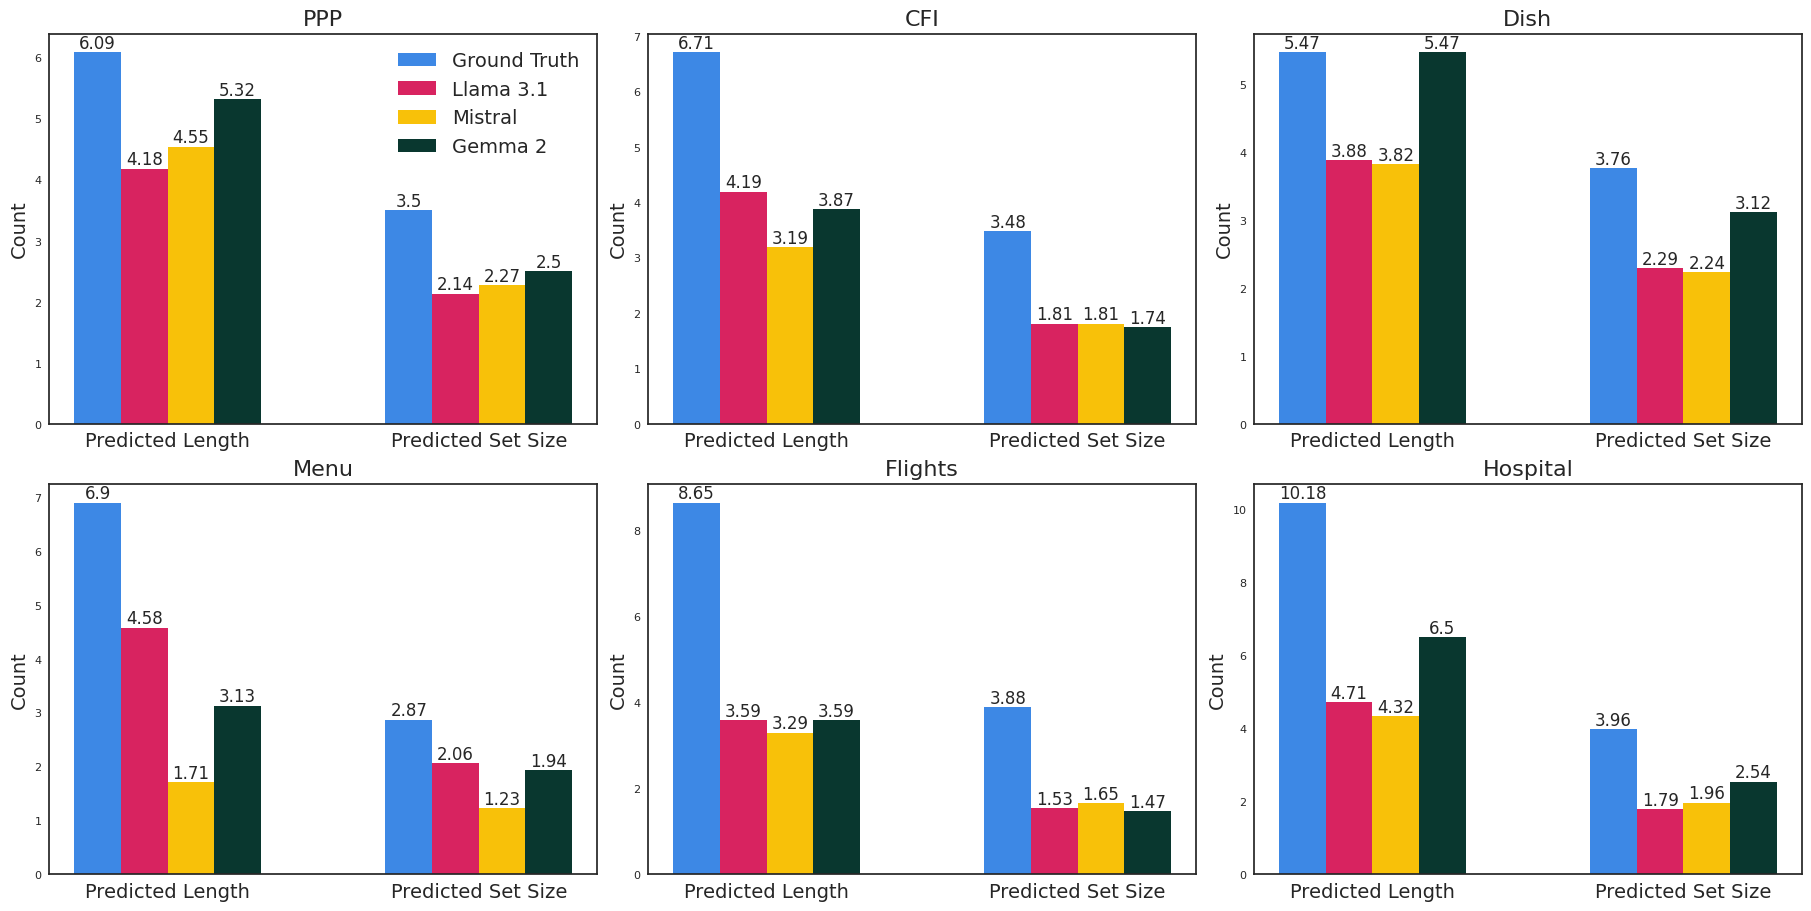

In [45]:


# Use an academic style for publication (ACL)
plt.style.use('seaborn-v0_8-white') #-whitegrid')

# Define datasets and models
datasets = ['PPP', 'CFI', 'Dish', 'Menu', 'Flights', 'Hospital']
models = ['Ground Truth', 'Llama 3.1', 'Mistral', 'Gemma 2']

n_models = len(models)
group_labels = ['Predicted Length', 'Predicted Set Size']
n_groups = len(group_labels)

# Example data arrays: each row corresponds to one dataset,
# and each column corresponds to one model.
# Define a color-blind friendly palette for 4 models
# model_colors = ["#377eb8", "#e41a1c", "#4daf4a", "#984ea3"]
model_colors = ["#3d88e5", "#d82360", "#f8c109", "#09372f"]

# Set up a 2 x 3 grid of subplots with constrained layout for a tighter fit
fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
axes = axes.flatten()

# Bar width for each model within a group
bar_width = 0.15
# Total width occupied by all model bars in a group
total_bar_width = n_models * bar_width

# x positions for the groups (center positions)
group_x = np.arange(n_groups)

for idx, ax in enumerate(axes):
    if idx >= len(datasets):
        break

    # For each dataset, extract values for predicted length and set size.
    length_vals = predicted_length[idx]
    set_size_vals = predicted_set_size[idx]
    
    # Plot bars for each group
    for group in range(n_groups):
        # For each model, compute its x position within the group.
        for j in range(n_models):
            # Calculate the x position so that bars are centered in each group.
            x_pos = group_x[group] - (total_bar_width / 2) + j * bar_width + bar_width / 2
            # Choose the appropriate value for the current group
            value = length_vals[j] if group == 0 else set_size_vals[j]
            # Draw the bar
            bar = ax.bar(x_pos, value, width=bar_width, color=model_colors[j],
                         label=models[j] if group == 0 and idx == 0 else "")
            # Add value label above each bar
            ax.text(x_pos, value, f'{round(value,2)}', ha='center', va='bottom', fontsize=12)

    # Set title and labels for the subplot
    ax.set_title(datasets[idx], fontsize=16)
    ax.set_xticks(group_x)
    ax.set_xticklabels(group_labels, fontsize=14)
    # ax.set_xlabel('Metrics', fontsize=14)
    ax.set_ylabel('Count', fontsize=14)

# Only add legend to the first subplot to avoid redundancy
axes[0].legend(fontsize=14, loc='upper right')

plt.savefig("ops_length_viz.pdf", format="pdf")

plt.show()

In [8]:
df_ops_stats_viz=pd.read_csv('/projects/bces/lanl2/LLM4DC/ops_stats_viz.csv')

In [9]:
df_ops_stats_viz.iloc[:,1:].values

array([[19, 19, 11,  2, 11, 24],
       [16, 16, 16,  1, 16,  0],
       [13, 17, 21,  0, 16, 13],
       [16, 17,  0, 14, 13,  6],
       [28, 28,  6,  0, 23, 28],
       [26, 27,  5,  4, 17, 28]])

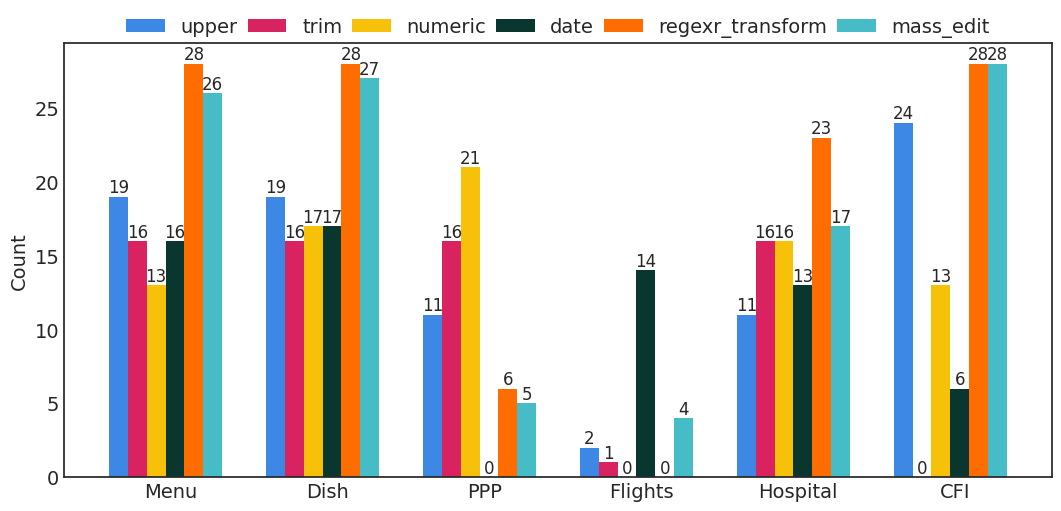

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Use an academic style for publication
plt.style.use('seaborn-v0_8-white')
plt.rcParams.update({'font.size': 14})

# Define operations and datasets
operations = ["upper","trim","numeric","date","regexr_transform","mass_edit"]
datasets = [ 'Menu', 'Dish','PPP', 'Flights', 'Hospital', 'CFI']
n_datasets = len(datasets)
n_operations = len(operations)

# Example count data: each row corresponds to one operation,
# and each column corresponds to one dataset.
# This array should be of shape (6, 6).
count_data = df_ops_stats_viz.iloc[:,1:].values.transpose()

# Define a color-blind friendly palette (ColorBrewer-inspired) for 6 datasets
colors = ["#3d88e5", "#d82360", "#f8c109", "#09372f", "#ff6d01", "#46bdc6"]

# Set up a single subplot with constrained layout
fig, ax = plt.subplots(figsize=(10.5, 5), constrained_layout=True)

# Bar width for each dataset's bar in a group
bar_width = 0.12
total_bar_width = n_datasets * bar_width  # total width for one operation group

# x positions for each operation group (centered)
group_x = np.arange(n_operations)

# Plot bars for each dataset within each operation group
for i in range(n_operations):
    # Compute the x positions for the current dataset's bars in each group.
    x_positions = group_x - (total_bar_width / 2) + i * bar_width + bar_width / 4
    ax.bar(x_positions, count_data[:, i], width=bar_width, color=colors[i], label=operations[i])
    
    # Add value labels above each bar
    for j, value in enumerate(count_data[:, i]):
        ax.text(x_positions[j], value, f'{value}', ha='center', va='bottom', fontsize=12)

# Set x-axis labels and title
ax.set_xticks(group_x)
# ax.set_xticklabels(operations, fontsize=14)
ax.set_xticklabels(datasets, fontsize=14)
# ax.set_xlabel('Operations', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
# ax.set_title('Count of Each Operation by Dataset', fontsize=16)

# Place the legend at the top in one line
ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=n_datasets,columnspacing=0.5, fontsize=14)
# plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15, 0.5, 0.2), ncol=2, columnspacing=0.5, handlelength=1, handletextpad=0.2)

# Save the plot as a PDF file
plt.savefig("ops_stats_viz.pdf", format="pdf")
plt.show()